In [4]:
# pip install pandas scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report


In [6]:
df = pd.read_csv(r"C:\Users\roshi\Downloads\spam .csv")

In [7]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [8]:
df['label_num'] = df.label.map({'ham':0, 'spam':1})

In [9]:
X = df['message']
y = df['label']

In [10]:
vectorizer = CountVectorizer()

X_vectorized = vectorizer.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = MultinomialNB()

In [13]:
model.fit(X_train, y_train)

MultinomialNB()

In [14]:
predictions = model.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, predictions)

print(accuracy)

0.97847533632287


In [16]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       965
        spam       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [22]:
sample = ["27,692 alumni from your school already solved LinkedIn puzzle games"]

sample_vector = vectorizer.transform(sample)

result = model.predict(sample_vector)

print(result)

['ham']


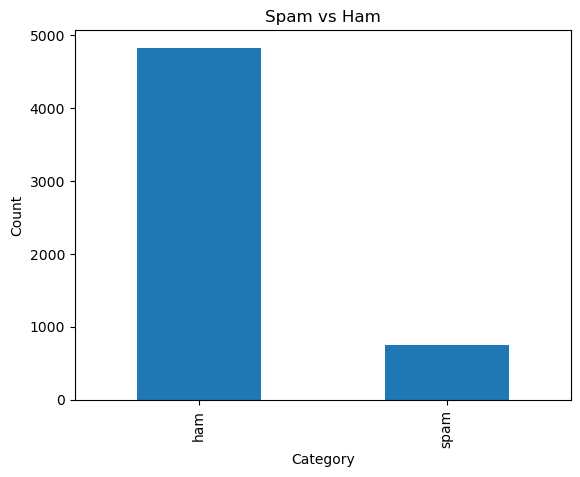

In [18]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Spam vs Ham")

plt.show()

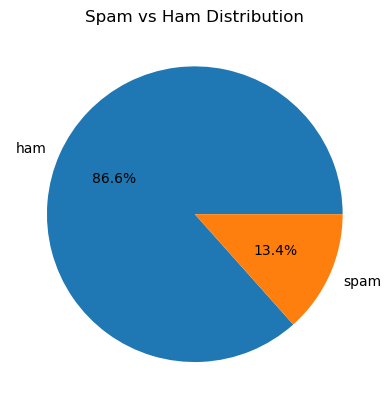

In [19]:
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Spam vs Ham Distribution")

plt.ylabel("")

plt.show()

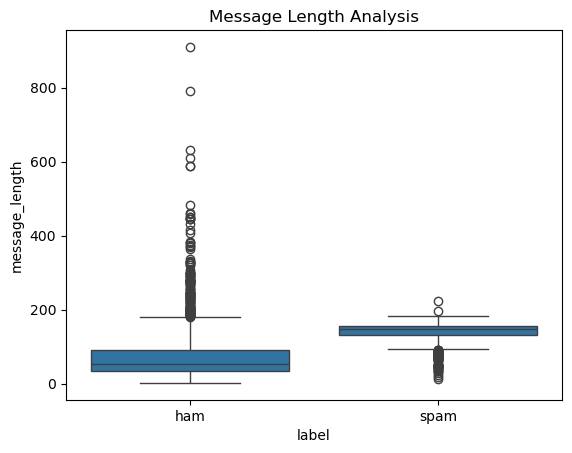

In [20]:
# Create message length column
df['message_length'] = df['message'].apply(len)

# Boxplot
import seaborn as sns

sns.boxplot(
    x='label',
    y='message_length',
    data=df
)

plt.title("Message Length Analysis")

plt.show()